In [1]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision
import numpy as np
import torch.nn as nn
import torch
import torch.optim as optim
import time

In [2]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

device(type='mps')

In [3]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])

In [4]:
train_dataset = datasets.CIFAR10(root='data',train=True,download=True,transform=transform)
test_dataset = datasets.CIFAR10(root='data',train=False,download=True,transform=transform)

In [5]:
len(train_dataset),len(test_dataset)

(50000, 10000)

In [6]:
images,labels = train_dataset[0]

In [7]:
images.shape

torch.Size([3, 32, 32])

In [8]:
images.squeeze().shape

torch.Size([3, 32, 32])

In [9]:
classes = ['plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
def show_img(images,title):
    img = images/2 + 0.5
    img  = img.numpy()
    plt.imshow(np.transpose(img,(1,2,0)))
    plt.axis("off")
    plt.title(title)
    plt.show()

In [11]:
batch_size = 100
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [12]:
len(train_loader)

500

In [13]:
for images,lables in train_loader:
    print(images.shape)
    break

torch.Size([100, 3, 32, 32])


In [14]:
len(images),len(lables)

(100, 100)

In [15]:
title = [classes[lable] for lable in lables[:8]]

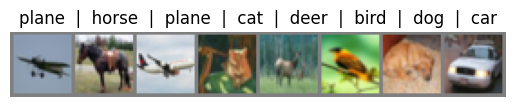

In [16]:
show_img(torchvision.utils.make_grid(images[:8]),"  |  ".join(title))

### Creating Neural Network

In [17]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3,32,(3,3),padding="same"), #in filter/channel(3: RGB), out_channel: 32, (32,32,32) -> 32 channel and 32x32 image 
            nn.ReLU(),
            nn.MaxPool2d((2,2),stride=(2,2)), # 32x16x16
            nn.Conv2d(32,64,kernel_size=(3,3)), # 64x14x14   (image size reduced by 2x2 since no padding)
            nn.ReLU(),
            nn.MaxPool2d((2,2),(2,2)) # 64x7x7
        )
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 600),
            nn.ReLU(),
            nn.Linear(600,120),
            nn.ReLU(),
            nn.Linear(120,10)
        )
    def forward(self,x):
        x = self.network(x)
        x = self.fc_layer(x)
        return x

In [18]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10
start_time = time.time()
for epoch in range(epochs):
    model.train()
    for batch ,(images,labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        #forward pass
        outputs = model(images)
        #backward pass
        optimizer.zero_grad()
        loss = criterion(outputs,labels)
        loss.backward()
        #weights update
        optimizer.step()

        if (batch+1)%100 ==0:
            print(f"Epoch {epoch+1}/{epochs}, Batch {batch+1}/{len(train_loader)}, Loss: {loss.item():.4f}")
end_time = time.time()
print(f"Training Time ==> {end_time-start_time} sec")
model.eval()
with torch.no_grad():
    all_pred, correct_pred = 0,0
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _,pred = torch.max(outputs,1)
        all_pred += len(images)
        correct_pred += (pred == labels).sum().item()

    print(f"Validation Accuracy on 10k test images --> {correct_pred*100/all_pred}%")
        
    

Epoch 1/10, Batch 100/500, Loss: 1.5469
Epoch 1/10, Batch 200/500, Loss: 1.2096
Epoch 1/10, Batch 300/500, Loss: 1.6538
Epoch 1/10, Batch 400/500, Loss: 1.3103
Epoch 1/10, Batch 500/500, Loss: 1.0186
Epoch 2/10, Batch 100/500, Loss: 1.0110
Epoch 2/10, Batch 200/500, Loss: 0.9181
Epoch 2/10, Batch 300/500, Loss: 0.9649
Epoch 2/10, Batch 400/500, Loss: 1.1519
Epoch 2/10, Batch 500/500, Loss: 0.8942
Epoch 3/10, Batch 100/500, Loss: 0.8176
Epoch 3/10, Batch 200/500, Loss: 0.8072
Epoch 3/10, Batch 300/500, Loss: 0.8731
Epoch 3/10, Batch 400/500, Loss: 0.7707
Epoch 3/10, Batch 500/500, Loss: 0.9565
Epoch 4/10, Batch 100/500, Loss: 0.5266
Epoch 4/10, Batch 200/500, Loss: 0.8047
Epoch 4/10, Batch 300/500, Loss: 0.4454
Epoch 4/10, Batch 400/500, Loss: 0.7183
Epoch 4/10, Batch 500/500, Loss: 0.5263
Epoch 5/10, Batch 100/500, Loss: 0.4756
Epoch 5/10, Batch 200/500, Loss: 0.4339
Epoch 5/10, Batch 300/500, Loss: 0.3524
Epoch 5/10, Batch 400/500, Loss: 0.4161
Epoch 5/10, Batch 500/500, Loss: 0.4690
